<h1> Bit Flip Error Code

In [1]:
from qiskit import __version__
assert __version__ >= "2.0.0", "Qiskit version must be at least 2.0.0"
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt

plt.style.use('dark_background')

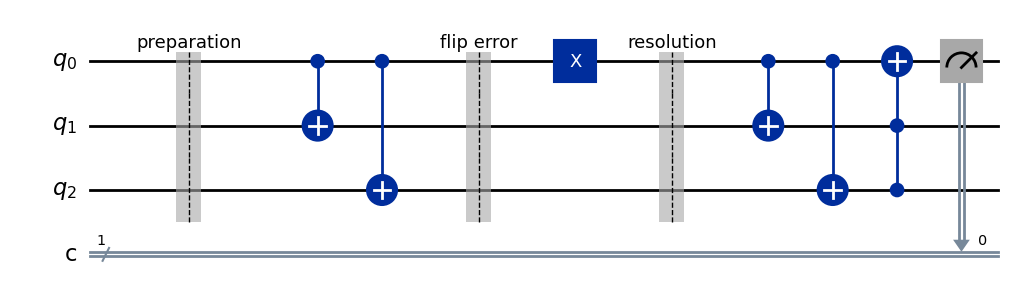

In [2]:
def bit_flip_circuit():

    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(1, 'c')

    qc = QuantumCircuit(qr, cr)

    qc.barrier(label='preparation')
    qc.cx(qr[0], qr[1])
    qc.cx(qr[0], qr[2])

    qc.barrier(label='flip error')

    qc.x(qr[0])

    qc.barrier(label='resolution')

    qc.cx(qr[0], qr[1])
    qc.cx(qr[0], qr[2])
    qc.ccx(qr[1], qr[2], qr[0])

    # qc.measure(qr, cr)
    qc.measure(qr[0], cr[0])
    
    return qc

bit_flip_circuit().draw(output='mpl')

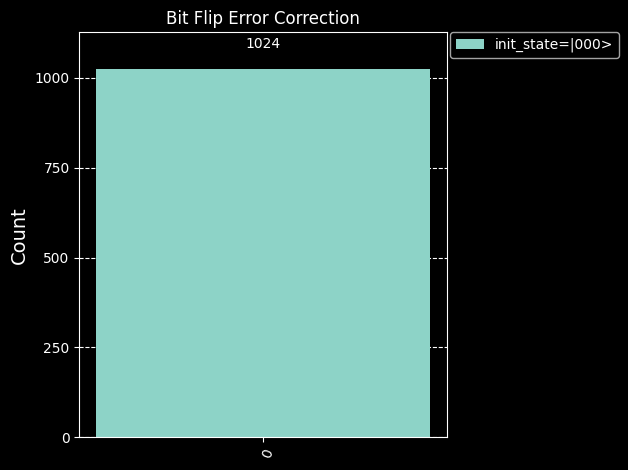

In [3]:
sim = AerSimulator(method='statevector')

qc_tr = transpile(bit_flip_circuit(), sim)
result = sim.run(qc_tr).result()
counts = result.get_counts()

plot_histogram(counts, legend=['init_state=|000>'], title='Bit Flip Error Correction')

<h2> Changing Error Position to Ancilla Qubits

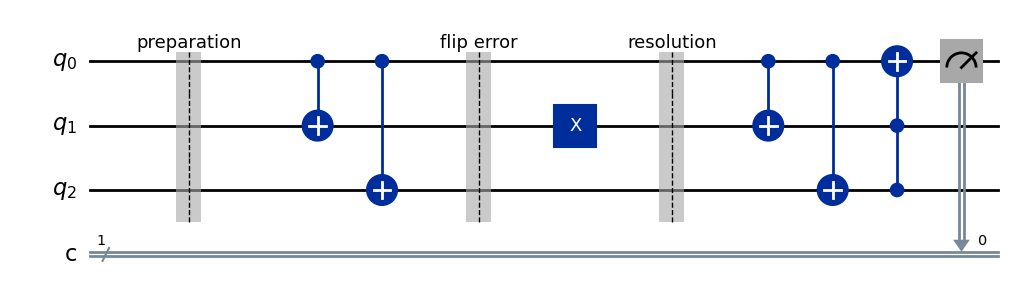

In [4]:
def bit_flip_circuit_2(i):

    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(1, 'c')

    qc = QuantumCircuit(qr, cr)

    qc.barrier(label='preparation')
    qc.cx(qr[0], qr[1])
    qc.cx(qr[0], qr[2])

    qc.barrier(label='flip error')

    qc.x(qr[i])

    qc.barrier(label='resolution')

    qc.cx(qr[0], qr[1])
    qc.cx(qr[0], qr[2])
    qc.ccx(qr[1], qr[2], qr[0])

    # qc.measure(qr, cr)
    qc.measure(qr[0], cr[0])
    
    return qc

bit_flip_circuit_2(1).draw(output='mpl')

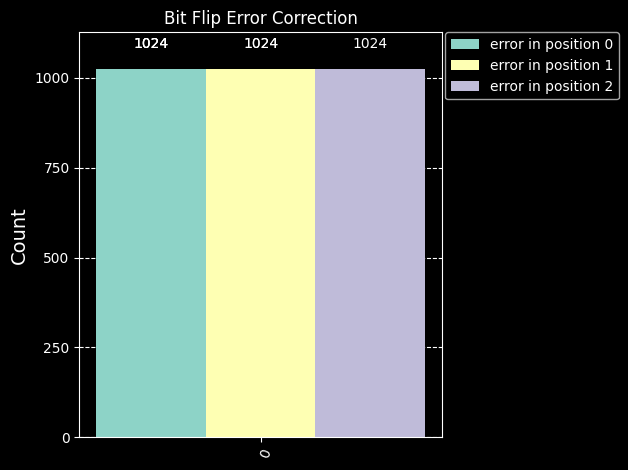

In [5]:
sim = AerSimulator(method='statevector')

qc_tr = transpile([bit_flip_circuit_2(i) for i in range(3)], sim)
result = sim.run(qc_tr).result()
counts = result.get_counts()

plot_histogram(counts, legend=[f'error in position {i}' for i in range(3)], title='Bit Flip Error Correction')